# Getting Started

This guide covers the core FactoriaX workflow end-to-end:

- Introduction to Factoriax.
- Breakdown of the observation space and action space.
- Running rollouts: Python loop, vmap, and lax.scan.
- Play a game through the interface.
- Scenarios (easy rocket).
- Saving replays.
- Creating visualizations and replays.

**Prerequisites**: install the package with `uv sync` (or `pip install factoriax`).

## Introduction

FactoriaX is a JAX-native reinforcement-learning environment inspired by Factorio.
The goal is to automate production lines and ultimately launch a rocket, starting
from raw ore and progressing through smelting, assembly, and science research.

The environment follows the [gymnax](https://github.com/RobertTLange/gymnax) API.
A stateless `env` object and an `EnvParams` struct hold all configuration.
`env.reset_env` and `env.step_env` take explicit JAX keys and states and are
fully JIT-compilable and `jax.vmap`-able.

```python
env, params = env_from_name("EasyRocket-v1")
obs, state  = env.reset_env(key, params)
obs, state, reward, done, info = env.step_env(key, state, action, params)
```

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from factoriax.make import env_from_name

env, params = env_from_name("EasyRocket-v1")
obs, state = env.reset_env(jax.random.PRNGKey(0), params)

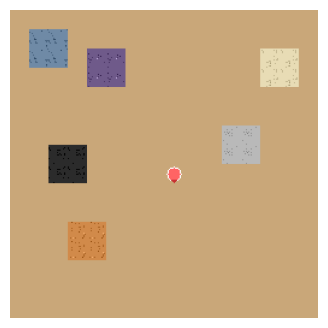

In [5]:
from factoriax.engine.jax_renderer import JaxRenderer

plt.figure(figsize=(4, 4))
plt.imshow(np.asarray(JaxRenderer(tile_px=16).jit_render_map(state)))
plt.axis("off")
plt.show()

## Observation space

FactoriaX supports two types of observation: **vector** and **image**.

**Vector observations** are flat float arrays returned directly by `reset_env` and
`step_env`. They are fully JIT-compatible and the standard input for neural-network
policies. Four variants are available:

| Variant | View | Shape | Notes |
|---------|------|-------|-------|
| `x_ray_global` | whole map | `(H*W*10 + 72,)` | sees slot contents and buried ore |
| `x_ray_local` | `(2r+1)×(2r+1)` window | `((2r+1)^2*10 + 72,)` | centred on player, `obs_radius` sets `r` |
| `superficial_global` | whole map | `(H*W*3 + 63,)` | only visible surface |
| `superficial_local` | `(2r+1)×(2r+1)` window | `((2r+1)^2*3 + 63,)` | centred on player |

**Image observations** are RGB arrays produced by `factoriax.engine.observations.rgb`.
They are not JIT-compatible and are intended for vision-based agents or visual
inspection.

Pass `obs=` to `env_from_name` to select a vector variant, and `obs_radius=` for
local variants.

In [6]:
# --- Vector observations ---
env_xg, params_xg = env_from_name("EasyRocket-v1", obs="x_ray_global")
env_xl, params_xl = env_from_name("EasyRocket-v1", obs="x_ray_local", obs_radius=5)
env_sg, params_sg = env_from_name("EasyRocket-v1", obs="superficial_global")
env_sl, params_sl = env_from_name("EasyRocket-v1", obs="superficial_local", obs_radius=5)

key = jax.random.PRNGKey(0)
obs_xg, _ = env_xg.reset_env(key, params_xg)
obs_xl, _ = env_xl.reset_env(key, params_xl)
obs_sg, _ = env_sg.reset_env(key, params_sg)
obs_sl, _ = env_sl.reset_env(key, params_sl)

print("x_ray_global shape:         ", obs_xg.shape)
print("x_ray_local (r=5) shape:    ", obs_xl.shape)
print("superficial_global shape:   ", obs_sg.shape)
print("superficial_local (r=5):    ", obs_sl.shape)
print()
print("dtype:", obs_xg.dtype, "  range: [", float(obs_xg.min()), ",", float(obs_xg.max()), "]")

x_ray_global shape:          (2632,)
x_ray_local (r=5) shape:     (1282,)
superficial_global shape:    (831,)
superficial_local (r=5):     (426,)

dtype: float32   range: [ 0.0 , 1.0 ]


Image obs shape: (512, 512, 3)   dtype: uint8
Note: rgb() is not JIT-compatible.


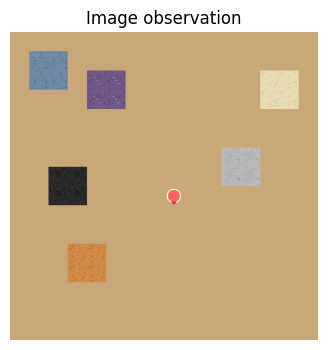

In [7]:
# --- Image observation ---
from factoriax.engine.observations import rgb

img_obs = rgb(state, block_pixel_size=32)

print("Image obs shape:", img_obs.shape, "  dtype:", img_obs.dtype)
print("Note: rgb() is not JIT-compatible.")

plt.figure(figsize=(4, 4))
plt.imshow(img_obs)
plt.axis("off")
plt.title("Image observation")
plt.show()

## Action space

Actions are flat integers. The space has **85 actions** split into five families:

| Family | Offsets | Count | Actions |
|--------|---------|-------|---------|
| Move / face | 0 – 8 | 9 | `NOOP`, `UP/DOWN/LEFT/RIGHT`, `FACE_UP/DOWN/LEFT/RIGHT` |
| Interact | 9 – 16 | 8 | `MINE`, `PICKUP`, `WITHDRAW`, `REPAIR`, `ROTATE_LEFT/RIGHT/UP/DOWN` |
| Place | 17 – 26 | 10 | `PLACE_<machine>`, one per placeable machine type |
| Craft | 27 – 52 | 26 | `CRAFT_<item>`, one per craftable item |
| Deposit | 53 – 84 | 32 | `DEPOSIT_<item>`, one per non-empty item |

Each action is **self-contained**: placement names the machine, deposit names the
item, so no slot cursor is needed. Invalid actions (e.g. placing on water) are
silently ignored.

In [8]:
from factoriax.engine.constants import (
    Action, MoveAction, InteractAction,
    NUM_ACTIONS, PLACE_BASE, CRAFT_BASE, DEPOSIT_BASE,
    PLACEMENT_ITEMS, CRAFT_ITEMS, DEPOSIT_ITEMS,
)

print(f"Total actions : {NUM_ACTIONS}")
print(f"Move          : 0 – {len(MoveAction) - 1}  ({len(MoveAction)} actions)")
print(f"Interact      : {len(MoveAction)} – {PLACE_BASE - 1}  ({len(InteractAction)} actions)")
print(f"Place         : {PLACE_BASE} – {CRAFT_BASE - 1}  ({len(PLACEMENT_ITEMS)} actions)")
print(f"Craft         : {CRAFT_BASE} – {DEPOSIT_BASE - 1}  ({len(CRAFT_ITEMS)} actions)")
print(f"Deposit       : {DEPOSIT_BASE} – {NUM_ACTIONS - 1}  ({len(DEPOSIT_ITEMS)} actions)")
print()
print("Place actions:", [a.name for a in Action if a.name.startswith("PLACE_")])

Total actions : 85
Move          : 0 – 8  (9 actions)
Interact      : 9 – 16  (8 actions)
Place         : 17 – 26  (10 actions)
Craft         : 27 – 52  (26 actions)
Deposit       : 53 – 84  (32 actions)

Place actions: ['PLACE_MINER', 'PLACE_PALLET', 'PLACE_CONVEYOR_BELT', 'PLACE_ASSEMBLER', 'PLACE_ARM', 'PLACE_ROCKET', 'PLACE_FURNACE', 'PLACE_SCIENCE_LAB', 'PLACE_SPLITTER', 'PLACE_CROSSING']


## Running rollouts

There are four ways to run rollouts in FactoriaX, each with a different
performance and memory profile.

| Method | Python overhead | Throughput | Memory |
|--------|-----------------|------------|--------|
| Python loop | High: one dispatch per step | Low | Minimal (1 state at a time) |
| `jax.vmap` | Moderate: one dispatch per step, N envs per call | Medium | N states resident on device |
| `jax.lax.scan` | None: one Python call per episode | High | O(T) trajectory in compiled graph |
| `vmap(lax.scan)` | None: one Python call per batch | Highest | N states x O(T) trajectory |

`vmap(lax.scan)` is the standard training pattern: a single XLA kernel runs N
environments in parallel for T steps each. One Python call per rollout batch,
maximum GPU utilisation. The tradeoff is a longer one-time compile and higher
peak memory use.

In [9]:
import time

from factoriax.make import env_from_name
from factoriax.engine.constants import Action

env_b, params_b = env_from_name("EasyRocket-v1")
NOOP   = int(Action.NOOP)
N_ENVS = 32     # parallel environments for vmap
N_REPS = 3      # steady-state repetitions

# Steps per method — fewer for the Python loop (Python dispatch is the bottleneck),
# more for scan (amortises the longer compile over more useful work).
LOOP_STEPS = 10
VMAP_STEPS = 10
SCAN_STEPS = 500

print(f"Loop: {LOOP_STEPS} steps | vmap: {VMAP_STEPS} steps x {N_ENVS} envs | scan: {SCAN_STEPS} steps")

Loop: 10 steps | vmap: 10 steps x 32 envs | scan: 500 steps


In [10]:
# ---- Python loop ----
# JIT compiles a single step on first call. Python drives the loop.

step_jit = jax.jit(env_b.step_env)

def run_loop(seed):
    key = jax.random.PRNGKey(seed)
    _, state = env_b.reset_env(key, params_b)
    for _ in range(LOOP_STEPS):
        key, sk = jax.random.split(key)
        _, state, _, _, _ = step_jit(sk, state, NOOP, params_b)
    jax.block_until_ready(state.player_inventory)

t0 = time.perf_counter()
run_loop(0)
loop_startup = time.perf_counter() - t0

t0 = time.perf_counter()
for i in range(1, N_REPS + 1):
    run_loop(i)
loop_steady = (time.perf_counter() - t0) / N_REPS
loop_sps = LOOP_STEPS / loop_steady

print(f"Python loop  startup : {loop_startup:.2f}s")
print(f"             steady  : {loop_steady:.3f}s  ->  {loop_sps:,.0f} steps/s")

Python loop  startup : 6.62s
             steady  : 0.145s  ->  69 steps/s


In [ ]:
# ---- vmap ----
# vmap_reset captures params_b as a closure so its fields (map_height, map_width)
# remain concrete at JIT trace time. Passing params as a function argument makes
# those fields abstract, which breaks jnp.full() shape inference in the reset.
# vmap_step receives params as a normal argument — step_env only uses params
# fields as values (bounds checks, rates), never as array shapes, so it is fine.

@jax.jit
def vmap_reset(keys):
    return jax.vmap(env_b.reset_env, in_axes=(0, None))(keys, params_b)

vmap_step = jax.jit(jax.vmap(env_b.step_env, in_axes=(0, 0, 0, None)))

def run_vmap(seed):
    key = jax.random.PRNGKey(seed)
    _, states = vmap_reset(jax.random.split(key, N_ENVS))
    actions = jnp.full(N_ENVS, NOOP, jnp.int32)
    for _ in range(VMAP_STEPS):
        key, sk = jax.random.split(key)
        _, states, _, _, _ = vmap_step(jax.random.split(sk, N_ENVS), states, actions, params_b)
    jax.block_until_ready(states.player_inventory)

t0 = time.perf_counter()
run_vmap(0)
vmap_startup = time.perf_counter() - t0

t0 = time.perf_counter()
for i in range(1, N_REPS + 1):
    run_vmap(i)
vmap_steady = (time.perf_counter() - t0) / N_REPS
vmap_sps = VMAP_STEPS * N_ENVS / vmap_steady

print(f"vmap ({N_ENVS} envs) startup : {vmap_startup:.2f}s")
print(f"               steady  : {vmap_steady:.3f}s  ->  {vmap_sps:,.0f} env-steps/s")

In [ ]:
# ---- lax.scan ----
# The full T-step rollout is compiled into a single XLA program.
# run_scan_single is also reused for the vmap(scan) benchmark below.

def scan_body(carry, _):
    key, state = carry
    key, sk = jax.random.split(key)
    _, state, r, _, _ = env_b.step_env(sk, state, NOOP, params_b)
    return (key, state), r

def run_scan_single(key):
    _, state = env_b.reset_env(key, params_b)
    (_, state), rewards = jax.lax.scan(scan_body, (key, state), None, length=SCAN_STEPS)
    return rewards

run_scan = jax.jit(run_scan_single)

t0 = time.perf_counter()
jax.block_until_ready(run_scan(jax.random.PRNGKey(0)))
scan_startup = time.perf_counter() - t0

t0 = time.perf_counter()
for i in range(1, N_REPS + 1):
    jax.block_until_ready(run_scan(jax.random.PRNGKey(i)))
scan_steady = (time.perf_counter() - t0) / N_REPS
scan_sps = SCAN_STEPS / scan_steady

print(f"lax.scan     startup : {scan_startup:.2f}s  (compiles full {SCAN_STEPS}-step graph)")
print(f"             steady  : {scan_steady:.3f}s  ->  {scan_sps:,.0f} steps/s")

In [ ]:
# ---- vmap(lax.scan) ----
# The standard training pattern. One compiled XLA kernel runs N_ENVS environments
# in parallel for SCAN_STEPS each. A single Python call per rollout batch.

run_scan_vmap = jax.jit(jax.vmap(run_scan_single))

init_keys = jax.random.split(jax.random.PRNGKey(0), N_ENVS)
t0 = time.perf_counter()
jax.block_until_ready(run_scan_vmap(init_keys))
scan_vmap_startup = time.perf_counter() - t0

t0 = time.perf_counter()
for i in range(1, N_REPS + 1):
    keys_i = jax.random.split(jax.random.PRNGKey(i * 100), N_ENVS)
    jax.block_until_ready(run_scan_vmap(keys_i))
scan_vmap_steady = (time.perf_counter() - t0) / N_REPS
scan_vmap_sps = SCAN_STEPS * N_ENVS / scan_vmap_steady

print(f"vmap(scan) ({N_ENVS} envs) startup : {scan_vmap_startup:.2f}s")
print(f"                   steady  : {scan_vmap_steady:.3f}s  ->  {scan_vmap_sps:,.0f} env-steps/s")

In [ ]:
# ---- Performance summary ----

methods  = [
    f"Python loop\n(1 env, {LOOP_STEPS} steps)",
    f"vmap\n({N_ENVS} envs, {VMAP_STEPS} steps)",
    f"lax.scan\n(1 env, {SCAN_STEPS} steps)",
    f"vmap(scan)\n({N_ENVS} envs, {SCAN_STEPS} steps)",
]
startups = [loop_startup, vmap_startup, scan_startup, scan_vmap_startup]
sps      = [loop_sps, vmap_sps, scan_sps, scan_vmap_sps]
colours  = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars1 = ax1.bar(methods, startups, color=colours)
ax1.set_title("Startup time (JIT compilation)")
ax1.set_ylabel("Seconds")
ax1.set_yscale("log")
ax1.grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, startups):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1,
             f"{val:.1f}s", ha="center", va="bottom", fontsize=9)

bars2 = ax2.bar(methods, sps, color=colours)
ax2.set_title("Throughput (env-steps / second)")
ax2.set_ylabel("Steps / s")
ax2.set_yscale("log")
ax2.grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, sps):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.1,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("FactoriaX rollout benchmarks", fontsize=13)
plt.tight_layout()
plt.show()

print("Memory tradeoff:")
print(f"  Python loop  — 1 state at a time. Minimal device memory.")
print(f"  vmap         — {N_ENVS} states resident simultaneously.")
print(f"  lax.scan     — Trajectory outputs in the compiled graph (O(T) per env).")
print(f"  vmap(scan)   — {N_ENVS} x O(T); longest compile, highest throughput.")

## Play a game through the interface

FactoriaX ships a pygame-based interactive client that lets you play the game
manually. It is useful for understanding the mechanics and building intuition before
designing reward functions.

Launch it from a terminal (not from inside a notebook):

```bash
python -m factoriax.playground.play
```

**Controls:**

| Key | Action |
|-----|--------|
| W A S D | Move player |
| Space | Mine ore at current tile |
| E | Place or pick up machine, transfer items to machine, or craft item |
| F | Inspect machine in front of player |
| I | Toggle inventory / crafting menu |
| A / D | Select inventory slot (wraps to crafting panel) |
| W / S | Navigate rows in inventory / crafting panel |
| P | Toggle achievement menu |
| 1–8 | Quick-select inventory slot |
| Shift+1–2 | Quick-select slots 9–10 |
| Ctrl+1–9 | Switch active player |
| Escape | Close menu / open pause menu |

The pygame client does **not** import the JAX training pipeline, so it starts
quickly and does not require a GPU.

You can also run the playable interface through python:

In [3]:
from factoriax.playground.play.main import main
main()

pygame 2.6.1 (SDL 2.28.4, Python 3.11.9)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Scenarios

FactoriaX registers scenarios with gymnax-style version ids. Two are built in:

| Id | Name | Map | Notes |
|----|------|-----|-------|
| `EasyRocket-v1` | Easy Rocket | 16×16 | Procgen map, 2000-step budget, fresh layout each episode (`resample=True`) |
| `Rocket-v1` | Rocket | 32×32 | Fixed map, furnace and assembler pre-placed, hand-craft masked, 8000-step budget |

`resample=True` means each `auto_reset` draws a fresh map rather than restoring
the initial state, which is important for curriculum learning and generalisation.

In [ ]:
from factoriax.engine.envs.registry import list_scenarios

for env_id, spec in list_scenarios():
    print(f"{env_id:20s}  resample={spec.resample}")
    print(f"  {spec.description}")
    print()

In [ ]:
# auto_reset=True wraps the env in AutoResetWrapper.
# reset_env is called automatically whenever done is True.

env_ar, params_ar = env_from_name("EasyRocket-v1", auto_reset=True)

key, reset_key = jax.random.split(jax.random.PRNGKey(7))
obs_ar, state_ar = env_ar.reset_env(reset_key, params_ar)

key, step_key = jax.random.split(key)
obs_ar, state_ar, reward, done, info = env_ar.step_env(
    step_key, state_ar, int(Action.NOOP), params_ar
)

print("reward:", float(reward), "  done:", bool(done))

## Saving replays

A `Trajectory` bundles actions and (optionally) full state arrays from an episode.
It saves to a compressed `.npz` file and round-trips via `Trajectory.save` and
`Trajectory.load`.

For training loops, `RolloutRecorder` slots in alongside your `collect_fn` with
zero changes to JIT'd code. Call `recorder.record(trajectories, env_states)` after
each collection step and `recorder.finish()` when done.

In [13]:
from factoriax.analysis.trajectory import Trajectory

env_r, params_r = env_from_name("EasyRocket-v1")
key = jax.random.PRNGKey(42)
key, reset_key = jax.random.split(key)
_, state_r = env_r.reset_env(reset_key, params_r)

step_jit = jax.jit(env_r.step_env)

T = 10
actions_list = []

for _ in range(T):
    key, step_key = jax.random.split(key)
    _, state_r, _, _, _ = step_jit(step_key, state_r, int(Action.NOOP), params_r)
    actions_list.append(int(Action.NOOP))

traj = Trajectory(actions=np.array(actions_list))
print(traj)

Trajectory(episodes=1, steps=10, players=1)


In [12]:
import tempfile
from pathlib import Path

tmp = Path(tempfile.mkdtemp()) / "demo_replay.npz"
traj.save(str(tmp))

loaded = Trajectory.load(str(tmp))
print("Loaded:", loaded)
print("Actions match:", np.array_equal(traj.actions, loaded.actions))

NameError: name 'traj' is not defined

## Creating visualizations and replays

`compose_frame_with_inventory` concatenates the map render and an inventory
panel side by side, which is the same layout used in training videos.
`write_video` encodes a list of such frames to an MP4 via FFMPEG.

For long rollouts with thousands of frames, use `write_video_streaming` instead.
It writes frames one at a time so peak memory stays bounded to a single frame.

In [ ]:
from factoriax.analysis.video import compose_frame_with_inventory, write_video

env_v, params_v = env_from_name("EasyRocket-v1")
key = jax.random.PRNGKey(99)
key, reset_key = jax.random.split(key)
_, state_v = env_v.reset_env(reset_key, params_v)

step_jit = jax.jit(env_v.step_env)

frames = []
for _ in range(30):
    frames.append(compose_frame_with_inventory(state_v, block_pixel_size=16))
    key, step_key = jax.random.split(key)
    _, state_v, _, _, _ = step_jit(step_key, state_v, int(Action.NOOP), params_v)

print(f"frame shape: {frames[0].shape}  ({len(frames)} frames)")

plt.figure(figsize=(8, 4))
plt.imshow(frames[0])
plt.axis("off")
plt.title("Map + inventory panel")
plt.show()

In [ ]:
video_path = Path(tempfile.mkdtemp()) / "demo.mp4"
write_video(video_path, frames, fps=10)
print("Saved:", video_path)

## Next steps

- {doc}`quick_start`: batched rollouts with `jax.vmap` and PPO training.
- {doc}`../api/index`: full API reference.